# AFC Claims Analysis

**Task 1** — Exploratory analysis and dashboard KPIs  
**Task 2** — Claim count and cost forecast for April–December 2026

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = 'AFC Case Study Data Scientist_claims_data.csv'
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 20)

## 1. Data

In [6]:
df = pd.read_csv(DATA_PATH, parse_dates=['claim_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   claim_id              2000 non-null   object        
 1   customer_id           2000 non-null   object        
 2   claim_date            2000 non-null   datetime64[ns]
 3   vehicle_type          2000 non-null   object        
 4   damage_category       2000 non-null   object        
 5   fault_type            2000 non-null   object        
 6   description           1920 non-null   object        
 7   estimated_cost_eur    1940 non-null   float64       
 8   actual_cost_eur       2000 non-null   float64       
 9   repair_duration_days  1960 non-null   float64       
 10  status                2000 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 172.0+ KB


In [7]:
df.describe()

,claim_date,estimated_cost_eur,actual_cost_eur,repair_duration_days
count,2000,1940.000000,2000.000000,1960.000000
mean,2024-08-12 12:41:45.600000,2574.792464,2586.127660,3.208163
min,2023-01-01 00:00:00,244.660000,233.200000,1.000000
25%,2023-10-24 00:00:00,1159.987500,1148.015000,1.000000
50%,2024-08-17 00:00:00,2018.455000,1975.385000,3.000000
75%,2025-05-30 00:00:00,3330.047500,3380.880000,5.000000
max,2026-02-27 00:00:00,15000.000000,17664.580000,12.000000
std,NaN,2009.729746,2069.222058,2.222566


In [8]:
for col in ['vehicle_type', 'damage_category', 'fault_type', 'status']:
    print(df[col].value_counts().to_string())
    print()

vehicle_type
PKW            1182
Transporter     423
LKW             251
Motorrad        144

damage_category
Karosserie    686
Elektronik    399
Glas          311
Motor         237
Fahrwerk      189
Interieur     178

fault_type
Eigenverschulden    689
Fremdverschulden    614
Naturereignis       298
Teilschuld          218
Vandalismus         181

status
abgeschlossen        1708
storniert             246
wartend_auf_teile      27
in_bearbeitung         19



In [9]:
df.isna().sum().to_frame('missing').assign(
    pct=lambda x: (x['missing'] / len(df) * 100).round(1)
)

,missing,pct
claim_id,0,0.0
customer_id,0,0.0
claim_date,0,0.0
vehicle_type,0,0.0
damage_category,0,0.0
fault_type,0,0.0
description,80,4.0
estimated_cost_eur,60,3.0
actual_cost_eur,0,0.0
repair_duration_days,40,2.0


### Why group-level imputation?

Before imputing missing values, we verify that costs and repair durations vary meaningfully across the grouping dimensions. If all groups looked the same, a global mean would suffice — but the heatmaps below show they don't.

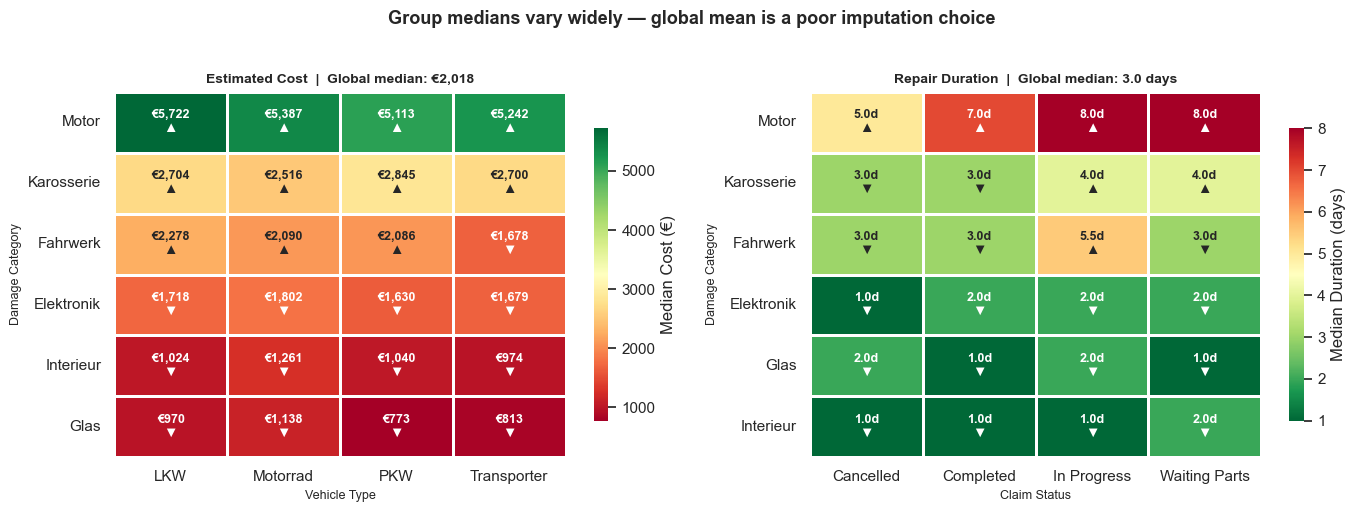

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Group medians vary widely — global mean is a poor imputation choice',
             fontsize=13, fontweight='bold', y=1.02)

# ── Left: estimated_cost_eur ─────────────────────────────────────
ax = axes[0]
pivot_cost = (
    df.groupby(['damage_category', 'vehicle_type'])['estimated_cost_eur']
    .median()
    .unstack()
)
pivot_cost = pivot_cost.loc[pivot_cost.median(axis=1).sort_values(ascending=False).index]
global_median_cost = df['estimated_cost_eur'].median()

annot_cost = pivot_cost.copy().astype(object)
for r in pivot_cost.index:
    for c in pivot_cost.columns:
        val = pivot_cost.loc[r, c]
        annot_cost.loc[r, c] = '' if pd.isna(val) else f'€{val:,.0f}\n{"▲" if val > global_median_cost else "▼"}'

sns.heatmap(pivot_cost, ax=ax, annot=annot_cost, fmt='', cmap='RdYlGn',
            linewidths=0.8, linecolor='white',
            annot_kws={'size': 9, 'weight': 'bold'},
            cbar_kws={'label': 'Median Cost (€)', 'shrink': 0.8})
ax.set_title(f'Estimated Cost  |  Global median: €{global_median_cost:,.0f}', fontsize=10, fontweight='bold')
ax.set_xlabel('Vehicle Type', fontsize=9)
ax.set_ylabel('Damage Category', fontsize=9)

# ── Right: repair_duration_days ───────────────────────────────────
ax = axes[1]
status_labels = {
    'abgeschlossen': 'Completed', 'in_bearbeitung': 'In Progress',
    'storniert': 'Cancelled', 'wartend_auf_teile': 'Waiting Parts'
}
df['status_en'] = df['status'].map(status_labels)

pivot_dur = (
    df.groupby(['damage_category', 'status_en'])['repair_duration_days']
    .median()
    .unstack()
)
pivot_dur = pivot_dur.loc[pivot_dur.median(axis=1).sort_values(ascending=False).index]
global_median_dur = df['repair_duration_days'].median()

annot_dur = pivot_dur.copy().astype(object)
for r in pivot_dur.index:
    for c in pivot_dur.columns:
        val = pivot_dur.loc[r, c]
        annot_dur.loc[r, c] = '' if pd.isna(val) else f'{val:.1f}d\n{"▲" if val > global_median_dur else "▼"}'

sns.heatmap(pivot_dur, ax=ax, annot=annot_dur, fmt='', cmap='RdYlGn_r',
            linewidths=0.8, linecolor='white',
            annot_kws={'size': 9, 'weight': 'bold'},
            cbar_kws={'label': 'Median Duration (days)', 'shrink': 0.8})
ax.set_title(f'Repair Duration  |  Global median: {global_median_dur:.1f} days', fontsize=10, fontweight='bold')
ax.set_xlabel('Claim Status', fontsize=9)
ax.set_ylabel('Damage Category', fontsize=9)

plt.tight_layout()
plt.show()

## 2. Preprocessing

In [11]:
# estimated_cost_eur: impute by damage_category x vehicle_type group median
# cost varies significantly across both dimensions, so global imputation would be misleading
group_med_cost = df.groupby(['damage_category', 'vehicle_type'])['estimated_cost_eur'].transform('median')
cat_med_cost   = df.groupby('damage_category')['estimated_cost_eur'].transform('median')
df['estimated_cost_eur'] = df['estimated_cost_eur'].fillna(group_med_cost).fillna(cat_med_cost)

# repair_duration_days: wartend_auf_teile claims are structurally longer,
# so duration should be imputed within the same damage_category x status cell
group_med_dur = df.groupby(['damage_category', 'status'])['repair_duration_days'].transform('median')
cat_med_dur   = df.groupby('damage_category')['repair_duration_days'].transform('median')
df['repair_duration_days'] = df['repair_duration_days'].fillna(group_med_dur).fillna(cat_med_dur)

# description: not used in any model; leave empty rows as-is

# Derived columns
df['year']          = df['claim_date'].dt.year
df['month']         = df['claim_date'].dt.month
df['quarter']       = df['claim_date'].dt.quarter
df['cost_delta']    = df['actual_cost_eur'] - df['estimated_cost_eur']
df['cost_delta_pct']= df['cost_delta'] / df['estimated_cost_eur']

# storniert claims are real operational events but carry no realized cost.
# Kept in the main dataset; excluded from cost and duration analyses via explicit filter.
active = df[df['status'] != 'storniert'].copy()

## 3. Exploratory Analysis

The EDA is framed from a **single customer's perspective** — mirroring how the dashboard will actually be used. Each chart answers a question a fleet manager would ask when logging in. CUST-002 is used as the example throughout; the same charts are generated per customer in production.

A secondary panel on each chart compares the customer against the portfolio average, which is the core of AFC's value proposition.

### Q1 — How are my total claim costs trending over time?

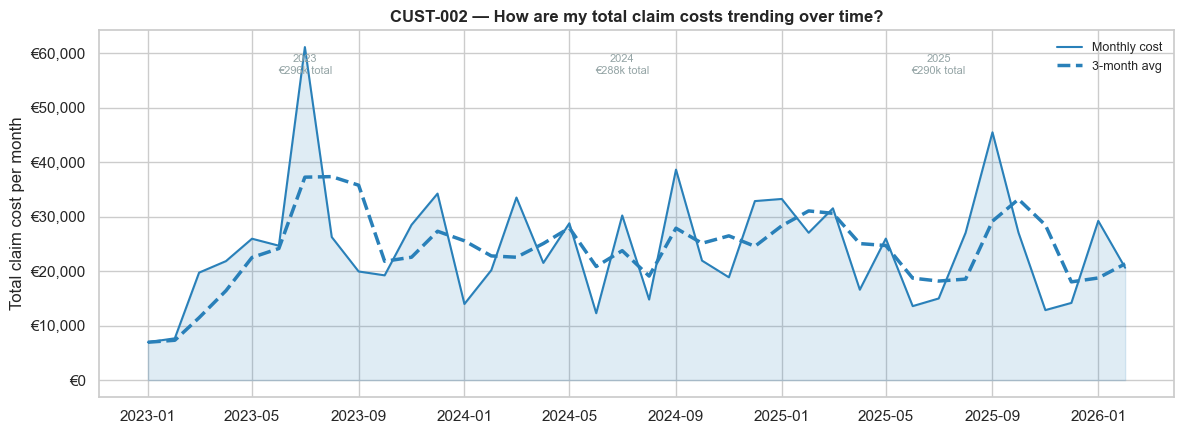

Peak month: €61,139 (Jul 2023)
Average monthly cost: €24,303


In [12]:
CUST = 'CUST-002'
cust = active[active['customer_id'] == CUST].copy()
port = active[active['customer_id'] != CUST].copy()
cust['month'] = cust['claim_date'].dt.to_period('M').dt.to_timestamp()
cust['year']  = cust['claim_date'].dt.year

monthly_cost = cust.groupby('month')['actual_cost_eur'].sum()
rolling_cost = monthly_cost.rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(monthly_cost.index, monthly_cost, alpha=0.15, color='#2980b9')
ax.plot(monthly_cost.index, monthly_cost, color='#2980b9', linewidth=1.5, label='Monthly cost')
ax.plot(rolling_cost.index, rolling_cost, color='#2980b9', linewidth=2.5, linestyle='--', label='3-month avg')

for yr, grp in cust.groupby('year'):
    if yr < 2026:
        total = grp['actual_cost_eur'].sum()
        mid   = pd.Timestamp(f'{yr}-07-01')
        ax.annotate(f'{yr}\n€{total/1000:.0f}k total',
                    xy=(mid, monthly_cost.max() * 0.92), fontsize=8,
                    color='#95a5a6', ha='center')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.set_ylabel('Total claim cost per month')
ax.set_title(f'{CUST} — How are my total claim costs trending over time?', fontweight='bold')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# Finding
print(f'Peak month: €{monthly_cost.max():,.0f} ({monthly_cost.idxmax().strftime("%b %Y")})')
print(f'Average monthly cost: €{monthly_cost.mean():,.0f}')

### Q2 — What damage types are driving my costs?

> **If I had more data:** The most valuable addition here would be **fleet size per customer** (number of vehicles managed). With that, we could normalise every cost metric to *cost per vehicle* and offer customers a truly fair benchmark against the portfolio average. For example:
> - *Your annual cost per vehicle: €X — portfolio average: €Y*
> - *Your claim rate per vehicle: X — portfolio average: Y*
> - *Your Motor repair cost per vehicle is 20% above average — here is what similar fleets look like*
>
> This turns the dashboard from a personal cost summary into a **competitive intelligence tool** — customers pay not just to see their own data, but to understand how they compare to the market. AFC sits on a unique dataset of 60,000 claims per year across many corporate fleets, and fleet-normalised benchmarks are an insight no customer could generate themselves. That is a defensible, high-value product feature.

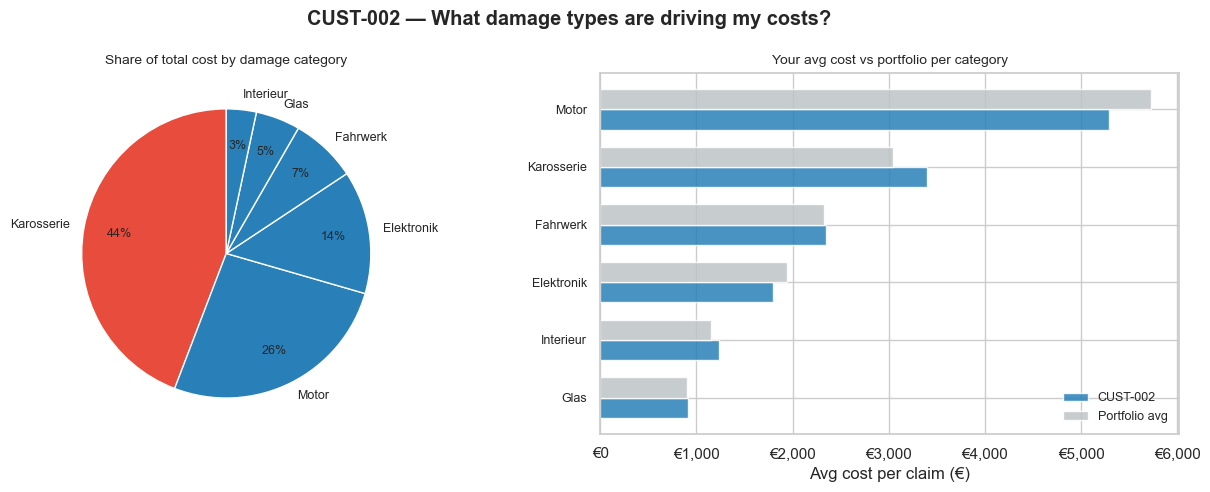

In [13]:
# ── Panel 1 & 2: cost by damage category ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_cost = cust.groupby('damage_category')['actual_cost_eur'].sum().sort_values(ascending=False)
colors_pie = ['#e74c3c' if c == cat_cost.idxmax() else '#2980b9' for c in cat_cost.index]
axes[0].pie(cat_cost, labels=cat_cost.index, autopct='%1.0f%%',
            colors=colors_pie, startangle=90, textprops={'fontsize': 9}, pctdistance=0.75)
axes[0].set_title('Share of total cost by damage category', fontsize=10)

cust_avg = cust.groupby('damage_category')['actual_cost_eur'].mean()
port_avg = port.groupby('damage_category')['actual_cost_eur'].mean()
comp = pd.DataFrame({'Your avg cost': cust_avg, 'Portfolio avg': port_avg}).dropna()
comp = comp.sort_values('Your avg cost', ascending=True)
x, w = np.arange(len(comp)), 0.35
axes[1].barh(x - w/2, comp['Your avg cost'], height=w, color='#2980b9', alpha=0.85, label=CUST)
axes[1].barh(x + w/2, comp['Portfolio avg'], height=w, color='#bdc3c7', alpha=0.85, label='Portfolio avg')
axes[1].set_yticks(x)
axes[1].set_yticklabels(comp.index, fontsize=9)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
axes[1].set_xlabel('Avg cost per claim (€)')
axes[1].set_title('Your avg cost vs portfolio per category', fontsize=10)
axes[1].legend(frameon=False, fontsize=9)

fig.suptitle(f'{CUST} — What damage types are driving my costs?', fontweight='bold')
plt.tight_layout()
plt.show()


### Q3 — How long are my vehicles off the road?

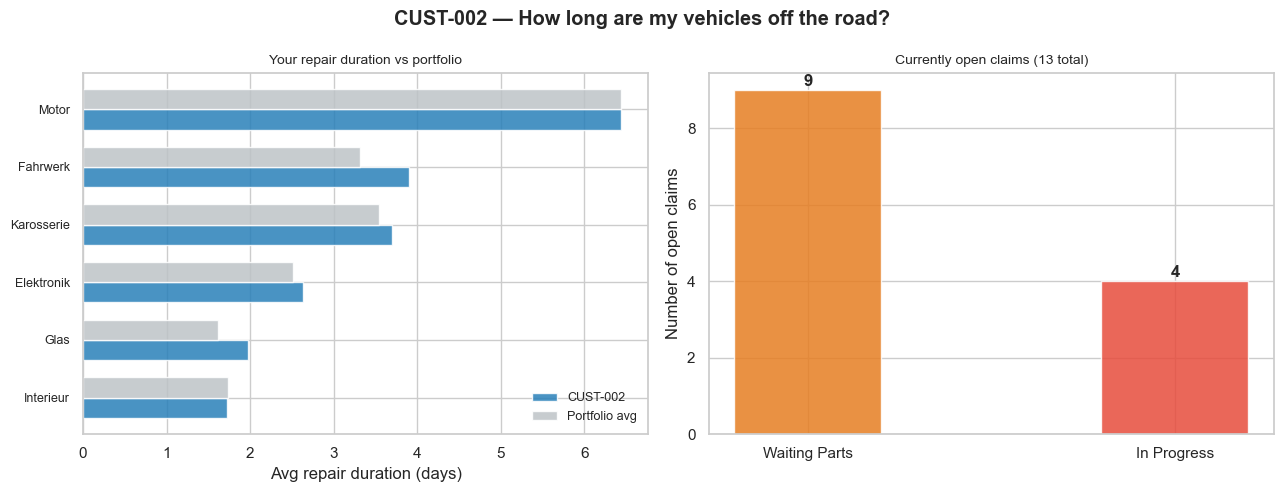

Open claims: 13
status
Waiting Parts    9
In Progress      4


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

resolved_cust = cust[cust['status'] == 'abgeschlossen']
resolved_port = port[port['status'] == 'abgeschlossen']

# Left: repair duration by category — customer vs portfolio
dur_cust = resolved_cust.groupby('damage_category')['repair_duration_days'].mean()
dur_port = resolved_port.groupby('damage_category')['repair_duration_days'].mean()
comp_dur = pd.DataFrame({'Your avg days': dur_cust, 'Portfolio avg': dur_port}).dropna()
comp_dur = comp_dur.sort_values('Your avg days', ascending=True)
x, w = np.arange(len(comp_dur)), 0.35
axes[0].barh(x - w/2, comp_dur['Your avg days'], height=w, color='#2980b9', alpha=0.85, label=CUST)
axes[0].barh(x + w/2, comp_dur['Portfolio avg'], height=w, color='#bdc3c7', alpha=0.85, label='Portfolio avg')
axes[0].set_yticks(x)
axes[0].set_yticklabels(comp_dur.index, fontsize=9)
axes[0].set_xlabel('Avg repair duration (days)')
axes[0].set_title('Your repair duration vs portfolio', fontsize=10)
axes[0].legend(frameon=False, fontsize=9)

# Right: open claims by status
open_claims = cust[cust['status'] != 'abgeschlossen']
status_labels = {'in_bearbeitung': 'In Progress', 'wartend_auf_teile': 'Waiting Parts'}
open_counts = open_claims['status'].map(status_labels).value_counts()
axes[1].bar(open_counts.index, open_counts.values,
            color=['#e67e22', '#e74c3c'], alpha=0.85, width=0.4)
for i, val in enumerate(open_counts.values):
    axes[1].text(i, val + 0.1, str(val), ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of open claims')
axes[1].set_title(f'Currently open claims ({len(open_claims)} total)', fontsize=10)

fig.suptitle(f'{CUST} — How long are my vehicles off the road?', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Open claims: {len(open_claims)}')
print(open_counts.to_string())

### Q4 — Which of my claims are preventable?

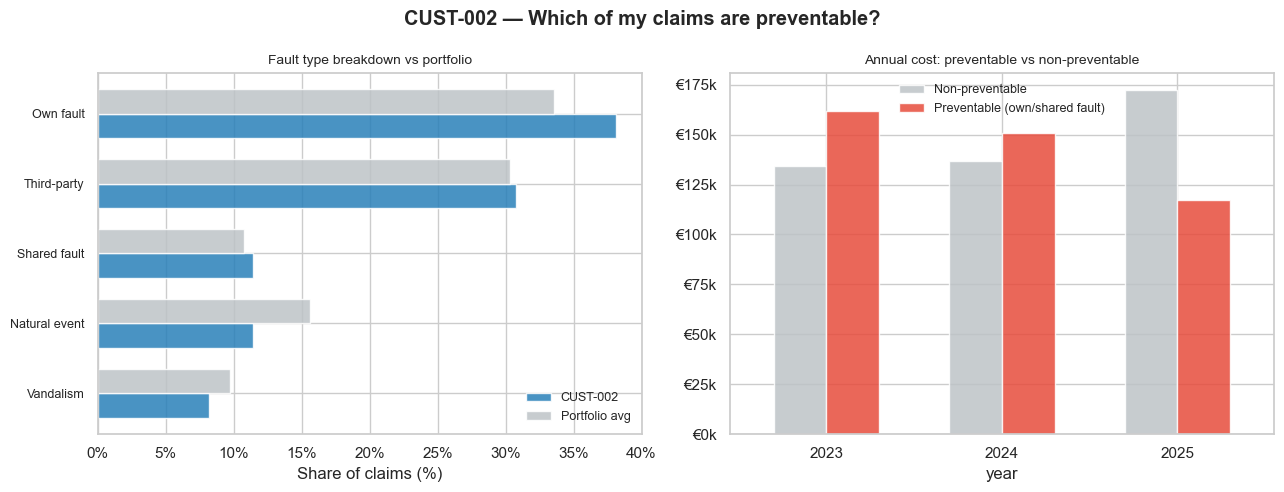

Preventable claims: 50% of total — €447,198 in reducible costs


In [15]:
fault_labels = {
    'Eigenverschulden': 'Own fault',   'Fremdverschulden': 'Third-party',
    'Naturereignis':    'Natural event','Teilschuld':       'Shared fault',
    'Vandalismus':      'Vandalism'
}
preventable_types = ['Own fault', 'Shared fault']
cust['fault_en'] = cust['fault_type'].map(fault_labels)
port['fault_en'] = port['fault_type'].map(fault_labels)
cust['preventable'] = cust['fault_en'].isin(preventable_types)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: fault type share — customer vs portfolio
fault_cust = cust['fault_en'].value_counts(normalize=True).mul(100)
fault_port = port['fault_en'].value_counts(normalize=True).mul(100)
fault_comp = pd.DataFrame({'Your share %': fault_cust, 'Portfolio avg %': fault_port}).fillna(0)
fault_comp = fault_comp.sort_values('Your share %', ascending=True)
x, w = np.arange(len(fault_comp)), 0.35
axes[0].barh(x - w/2, fault_comp['Your share %'],     height=w, color='#2980b9', alpha=0.85, label=CUST)
axes[0].barh(x + w/2, fault_comp['Portfolio avg %'],  height=w, color='#bdc3c7', alpha=0.85, label='Portfolio avg')
axes[0].set_yticks(x)
axes[0].set_yticklabels(fault_comp.index, fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[0].set_xlabel('Share of claims (%)')
axes[0].set_title('Fault type breakdown vs portfolio', fontsize=10)
axes[0].legend(frameon=False, fontsize=9)

# Right: annual cost — preventable vs non-preventable
yearly_fault = (cust.groupby(['year','preventable'])['actual_cost_eur']
    .sum().unstack(fill_value=0))
yearly_fault.columns = ['Non-preventable', 'Preventable (own/shared fault)']
yearly_fault = yearly_fault[yearly_fault.index < 2026]
yearly_fault.plot(kind='bar', ax=axes[1], color=['#bdc3c7','#e74c3c'],
                  alpha=0.85, width=0.6, edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
axes[1].set_xticklabels(yearly_fault.index, rotation=0)
axes[1].set_title('Annual cost: preventable vs non-preventable', fontsize=10)
axes[1].legend(frameon=False, fontsize=9)

fig.suptitle(f'{CUST} — Which of my claims are preventable?', fontweight='bold')
plt.tight_layout()
plt.show()

prev_pct  = cust['preventable'].mean() * 100
prev_cost = cust[cust['preventable']]['actual_cost_eur'].sum()
print(f'Preventable claims: {prev_pct:.0f}% of total — €{prev_cost:,.0f} in reducible costs')

### Q5 — How do I compare to the rest of the portfolio?

**The limitation this chart exposes**: Without fleet size data, raw claim frequency is dominated by company size, not risk. A company with 30 vehicles will always file more claims than one with 3 — that tells us nothing useful. The left column shows what the data gives us today. The right column shows what it would look like with fleet size normalisation, using a simulated fleet size as a documented assumption.

> **Assumption**: Fleet size is estimated as `annualised_claims ÷ 4`, based on an industry rule of thumb of 4 claims per vehicle per year. This is a simulation for illustrative purposes. Real fleet size data is the single most important missing variable in this dataset and would replace this assumption in production.

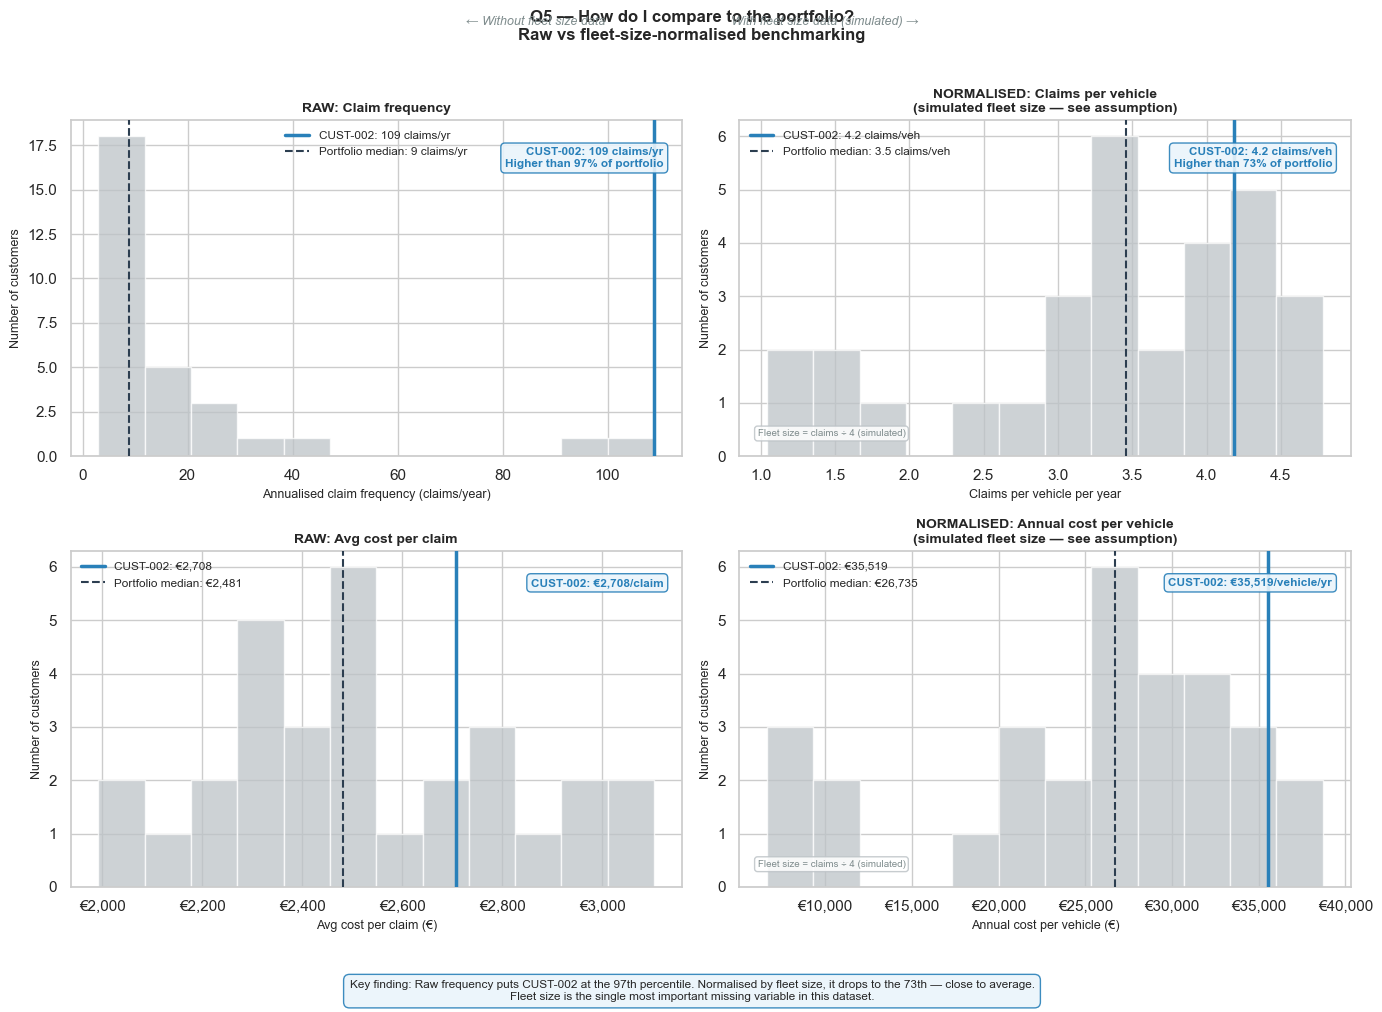

In [16]:
# Fleet size simulation — documented assumption
BASE_RATE = 4.0  # industry rule of thumb: ~4 claims/vehicle/year
np.random.seed(42)
cust_span = active.groupby('customer_id')['claim_date'].agg(['min','max'])
cust_span['months'] = ((cust_span['max'] - cust_span['min']).dt.days / 30.44).clip(lower=1)
cust_metrics = active.groupby('customer_id').agg(
    total_claims=('claim_id','count'),
    total_cost  =('actual_cost_eur','sum'),
    avg_cost    =('actual_cost_eur','mean'),
).join(cust_span[['months']])
cust_metrics['freq_rate']          = cust_metrics['total_claims'] / cust_metrics['months'] * 12
cust_metrics['fleet_size_simulated']= ((cust_metrics['freq_rate'] / BASE_RATE).round()
                                        .clip(lower=2).astype(int)
                                        + np.random.randint(-1, 2, size=len(cust_metrics)))
cust_metrics['fleet_size_simulated'] = cust_metrics['fleet_size_simulated'].clip(lower=2)
cust_metrics['claims_per_vehicle']   = cust_metrics['freq_rate'] / cust_metrics['fleet_size_simulated']
cust_metrics['cost_per_vehicle']     = cust_metrics['total_cost'] / cust_metrics['fleet_size_simulated']

cust_freq       = cust_metrics.loc[CUST, 'freq_rate']
cust_freq_norm  = cust_metrics.loc[CUST, 'claims_per_vehicle']
cust_cost       = cust_metrics.loc[CUST, 'avg_cost']
cust_cost_norm  = cust_metrics.loc[CUST, 'cost_per_vehicle']
port_freq_med      = cust_metrics['freq_rate'].median()
port_freq_norm_med = cust_metrics['claims_per_vehicle'].median()
port_cost_med      = cust_metrics['avg_cost'].median()
port_cost_norm_med = cust_metrics['cost_per_vehicle'].median()
pct_freq      = (cust_metrics['freq_rate'] < cust_freq).mean() * 100
pct_freq_norm = (cust_metrics['claims_per_vehicle'] < cust_freq_norm).mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Q5 — How do I compare to the portfolio?\nRaw vs fleet-size-normalised benchmarking',
             fontweight='bold', fontsize=12, y=0.98)

def draw_hist(ax, series, cust_val, port_med, cust_label, xlabel, title, subtitle, pct, fmt):
    ax.hist(series, bins=12, color='#bdc3c7', alpha=0.75, edgecolor='white', zorder=2)
    ax.axvline(cust_val, color='#2980b9', linewidth=2.5,
               label=f'{cust_label}: {fmt(cust_val)}', zorder=3)
    ax.axvline(port_med, color='#2c3e50', linewidth=1.5, linestyle='--',
               label=f'Portfolio median: {fmt(port_med)}', zorder=3)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Number of customers', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(frameon=False, fontsize=8.5)
    ax.text(0.97, 0.92, subtitle, transform=ax.transAxes, ha='right', va='top',
            fontsize=8.5, color='#2980b9', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='#eaf4fb', edgecolor='#2980b9', alpha=0.9))

draw_hist(axes[0,0], cust_metrics['freq_rate'], cust_freq, port_freq_med,
          CUST, 'Annualised claim frequency (claims/year)',
          'RAW: Claim frequency',
          f'{CUST}: {cust_freq:.0f} claims/yr\nHigher than {pct_freq:.0f}% of portfolio',
          pct_freq, fmt=lambda x: f'{x:.0f} claims/yr')

draw_hist(axes[0,1], cust_metrics['claims_per_vehicle'], cust_freq_norm, port_freq_norm_med,
          CUST, 'Claims per vehicle per year',
          'NORMALISED: Claims per vehicle\n(simulated fleet size — see assumption)',
          f'{CUST}: {cust_freq_norm:.1f} claims/veh\nHigher than {pct_freq_norm:.0f}% of portfolio',
          pct_freq_norm, fmt=lambda x: f'{x:.1f} claims/veh')
axes[0,1].text(0.03, 0.06, 'Fleet size = claims ÷ 4 (simulated)',
               transform=axes[0,1].transAxes, fontsize=7, color='#7f8c8d',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#bdc3c7', alpha=0.85))

draw_hist(axes[1,0], cust_metrics['avg_cost'], cust_cost, port_cost_med,
          CUST, 'Avg cost per claim (€)',
          'RAW: Avg cost per claim',
          f'{CUST}: €{cust_cost:,.0f}/claim',
          (cust_metrics['avg_cost'] < cust_cost).mean()*100,
          fmt=lambda x: f'€{x:,.0f}')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

draw_hist(axes[1,1], cust_metrics['cost_per_vehicle'], cust_cost_norm, port_cost_norm_med,
          CUST, 'Annual cost per vehicle (€)',
          'NORMALISED: Annual cost per vehicle\n(simulated fleet size — see assumption)',
          f'{CUST}: €{cust_cost_norm:,.0f}/vehicle/yr',
          (cust_metrics['cost_per_vehicle'] < cust_cost_norm).mean()*100,
          fmt=lambda x: f'€{x:,.0f}')
axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
axes[1,1].text(0.03, 0.06, 'Fleet size = claims ÷ 4 (simulated)',
               transform=axes[1,1].transAxes, fontsize=7, color='#7f8c8d',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#bdc3c7', alpha=0.85))

fig.text(0.5, 0.965,
         '← Without fleet size data                                    With fleet size data (simulated) →',
         ha='center', fontsize=9, color='#7f8c8d', style='italic')

fig.text(0.5, -0.01,
         f'Key finding: Raw frequency puts {CUST} at the 97th percentile. '
         f'Normalised by fleet size, it drops to the {pct_freq_norm:.0f}th — close to average.\n'
         f'Fleet size is the single most important missing variable in this dataset.',
         ha='center', fontsize=8.5,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#eaf4fb', edgecolor='#2980b9', alpha=0.9))

plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

## 4. Dashboard KPIs

In [17]:
# Claim frequency: annualised over each customer's observed window
cust_span = df.groupby('customer_id')['claim_date'].agg(['min', 'max'])
cust_span['months_active'] = ((cust_span['max'] - cust_span['min']).dt.days / 30.44).clip(lower=1)

cust_vol = df.groupby('customer_id').agg(
    total_claims=('claim_id', 'count'),
    cancelled   =('status', lambda x: (x == 'storniert').sum()),
)
cust_vol['cancellation_rate']    = cust_vol['cancelled'] / cust_vol['total_claims']
cust_vol['claim_frequency_rate'] = cust_vol['total_claims'] / cust_span['months_active'] * 12

resolved = active[active['status'] == 'abgeschlossen']
cust_resolved = resolved.groupby('customer_id').agg(
    avg_cost_per_claim  =('actual_cost_eur', 'mean'),
    avg_repair_duration =('repair_duration_days', 'mean'),
    estimation_accuracy =('cost_delta_pct', 'mean'),
)

kpis = cust_vol[['claim_frequency_rate', 'cancellation_rate']].join(cust_resolved)

In [18]:
kpis.sort_values('avg_cost_per_claim', ascending=False).style.format({
    'claim_frequency_rate'  : '{:.1f}',
    'cancellation_rate'     : '{:.1%}',
    'avg_cost_per_claim'    : '€{:,.0f}',
    'avg_repair_duration'   : '{:.1f}',
    'estimation_accuracy'   : '{:+.1%}',
}).background_gradient(subset=['avg_cost_per_claim'], cmap='YlOrRd')

,claim_frequency_rate,cancellation_rate,avg_cost_per_claim,avg_repair_duration,estimation_accuracy
customer_id,,,,,
CUST-020,9.0,10.7%,"€3,086",3.6,-2.0%
CUST-029,20.0,9.7%,"€3,070",3.5,-2.6%
CUST-009,17.9,10.7%,"€3,036",3.2,+4.1%
CUST-001,8.8,14.8%,"€2,948",3.4,+2.1%
CUST-027,9.1,7.4%,"€2,873",3.4,+5.4%
CUST-024,9.5,31.0%,"€2,751",2.6,-1.7%
CUST-018,12.6,8.1%,"€2,746",3.6,+2.8%
CUST-026,31.3,14.3%,"€2,721",3.6,-1.1%
CUST-002,123.9,12.1%,"€2,718",3.5,+0.3%


**KPI definitions**

| KPI | Formula | Unit |
|---|---|---|
| Claim Frequency Rate | claims ÷ months active × 12 | claims / year |
| Avg Cost per Resolved Claim | mean(actual_cost_eur), resolved only | EUR |
| Estimation Accuracy | mean((actual − estimated) / estimated) | % delta |
| Cancellation Rate | cancelled ÷ all claims | % |
| Avg Repair Duration | mean(repair_duration_days), resolved only | days |

---

**Which KPIs are most valuable for the sales team, and why?**

The sales team uses the same dashboard to demonstrate AFC's value to prospects. Of the five KPIs above, three land most powerfully in that context:

| KPI | Sales value | Why it lands |
|---|---|---|
| **Claim Frequency Rate** | ★★★ Highest | Enables the benchmark comparison — *'companies like yours average X claims/year, our customers average Y.'* This is the most direct proof of AFC's active management impact. |
| **Avg Repair Duration** | ★★★ Highest | Fleet operators treat vehicle downtime as a direct operational cost. Faster repair times translate immediately into a € saving the prospect can calculate themselves. |
| **Avg Cost per Resolved Claim** | ★★ Medium | Useful for demonstrating cost efficiency, but harder to attribute to AFC alone vs external factors like damage severity or vehicle mix. Still a strong supporting number. |
| **Estimation Accuracy** | ★★ Medium | Builds trust in AFC's predictability — a prospect can plan their fleet budget more reliably. Less visceral than frequency or downtime. |
| **Cancellation Rate** | ★ Lower | Primarily an internal quality metric. Meaningful for AFC operations but not compelling to a prospect. |

**The sales sequence**: lead with Claim Frequency Rate (benchmark proof), follow with Avg Repair Duration (operational savings), and close with the forecast from Task 2 — showing the prospect exactly what their expected costs look like for the rest of the year under AFC management.

## 5. Forecasting

### Approach

**The problem in plain terms:** given everything we know about a customer's claim history, predict how many claims and how much cost to expect between April and December 2026.

This hides three sub-problems that shape every modelling decision below:

1. **Claims are counts, not continuous values** — they are 0, 1, 2, 3... and can never be negative. Standard linear regression can predict negative numbers, which makes no sense here.
2. **Very little data per customer** — ~36 monthly observations each, with most months showing 0 or 1 claims. Too sparse for individual time series models.
3. **We need uncertainty, not just a point estimate** — telling a customer 'expect 8 claims' is less useful than 'expect between 5 and 12 claims.'

---

**Why not ARIMA or Prophet?**

These are the classic time series tools and the obvious first instinct. They are rejected here for two reasons. First, both need at least two full seasonal cycles of data per series to produce reliable intervals — we barely have that. Second, and more critically, fitting a separate model per customer means each model trains on only ~36 rows. With most values being 0 or 1, there is not enough signal for individual time series models to learn from.

---

**Why a pooled Poisson GLM?**

Instead of fitting 30 separate models, all customers are pooled into one. This means the model trains on 30 customers × 36 months = ~1,080 rows rather than 36. The shared learning is the key advantage — seasonal patterns and trends are learned from the whole portfolio, not from one customer's sparse history.

The Poisson GLM is chosen specifically because it handles count data natively. It predicts the *log* of the expected count, then exponentiates — which guarantees predictions are always positive. It also produces calibrated confidence intervals through Poisson probability math.

---

**Core assumption — uniform seasonality**

Pooling all customers into one model requires an explicit assumption: **seasonality affects all customers in the same way.** The `month_of_year` coefficient is a single number learned from the whole portfolio. It captures the average seasonal effect — if claims tend to be higher in winter across the portfolio, that signal is captured once and applied to everyone.

This is likely an approximation rather than strictly true. A customer operating heavy trucks on winter roads may have a very different seasonal profile than a customer with a small urban car fleet. If individual customers show strongly divergent seasonal patterns, a single pooled coefficient will be wrong for most of them.

This assumption is documented here and should be validated in production by checking per-customer seasonal residuals.

---

**How the model produces different results per customer despite sharing coefficients**

The coefficients — the learned weights — are identical for every customer. What differs are the *inputs*. Each customer is scored with their own `rolling_12m_rate`, their own `customer_enc`, and the same month and year. The `rolling_12m_rate` in particular carries most of the individual signal — CUST-002 has a rate of ~9 claims/month while CUST-007 has ~0.8, and those different inputs produce dramatically different predictions even through the same formula.

Concretely, for any customer C in month M the model computes:

```
log(predicted claims) = intercept
                      + β₁ × customer_enc
                      + β₂ × month_of_year      ← same coefficient, different month
                      + β₃ × year
                      + β₄ × rolling_12m_rate   ← same coefficient, very different value per customer
```

The β coefficients are shared. The input values are customer-specific. The output is therefore customer-specific.

---

**The tradeoff of pooling — known limitations**

| | Pooled model (used here) | Separate model per customer |
|---|---|---|
| Data efficiency | High — ~1,080 training rows | Low — ~36 rows each |
| Captures individual seasonality | No — shared assumption | Yes |
| Risk of dominant customers distorting results | Yes — CUST-002 has 10× more rows | No |
| Works for new customers | Yes — falls back to portfolio patterns | No |
| Complexity | Low — one model to maintain | High — 30 models |

Given the data size, pooling is the correct tradeoff. The shared seasonality assumption is the main limitation to flag.

---

**Train / test / forecast split**

- **Train**: Jan 2023 – Sep 2025
- **Test**: Oct – Dec 2025 *(held out — never seen during training)*
- **Forecast**: Apr – Dec 2026

Temporal split only — random row shuffling would leak future data into training and produce artificially optimistic evaluation metrics.

In [19]:
TODAY      = pd.Timestamp('2026-03-09')
TRAIN_END  = pd.Timestamp('2025-09-30')
TEST_START = pd.Timestamp('2025-10-01')
TEST_END   = pd.Timestamp('2025-12-31')

hist = df[df['claim_date'] <= TODAY].copy()

# Complete customer x month panel so zero-claim months are explicit
all_months    = pd.date_range(
    hist['claim_date'].min().to_period('M').to_timestamp(),
    hist['claim_date'].max().to_period('M').to_timestamp(),
    freq='MS'
)
all_customers = hist['customer_id'].unique()

grid = (
    pd.MultiIndex.from_product([all_customers, all_months], names=['customer_id', 'month'])
    .to_frame(index=False)
)
grid['month'] = pd.to_datetime(grid['month'])

monthly_counts = (
    hist.assign(month=hist['claim_date'].dt.to_period('M').dt.to_timestamp())
    .groupby(['customer_id', 'month'])['claim_id']
    .count()
    .reset_index(name='claim_count')
)

panel = (
    grid.merge(monthly_counts, on=['customer_id', 'month'], how='left')
    .fillna({'claim_count': 0})
)
panel['claim_count']   = panel['claim_count'].astype(int)
panel['month_of_year'] = panel['month'].dt.month
panel['year']          = panel['month'].dt.year
panel = panel.sort_values(['customer_id', 'month']).reset_index(drop=True)

# Rolling 12-month claim rate shifted by 1 to prevent leakage into the current month
customer_mean = panel.groupby('customer_id')['claim_count'].transform('mean')
panel['rolling_12m_rate'] = (
    panel.groupby('customer_id')['claim_count']
    .transform(lambda x: x.shift(1).rolling(12, min_periods=3).mean())
)
panel['rolling_12m_rate'] = panel['rolling_12m_rate'].fillna(customer_mean)

le = LabelEncoder()
panel['customer_enc'] = le.fit_transform(panel['customer_id'])

panel.head()

,customer_id,month,claim_count,month_of_year,year,rolling_12m_rate,customer_enc
0,CUST-001,2023-01-01,1,1,2023,0.710526,0
1,CUST-001,2023-02-01,1,2,2023,0.710526,0
2,CUST-001,2023-03-01,1,3,2023,0.710526,0
3,CUST-001,2023-04-01,1,4,2023,1.000000,0
4,CUST-001,2023-05-01,1,5,2023,1.000000,0


In [20]:
FEATURES = ['customer_enc', 'month_of_year', 'year', 'rolling_12m_rate']

train = panel[panel['month'] <= TRAIN_END].copy()
test  = panel[(panel['month'] >= TEST_START) & (panel['month'] <= TEST_END)].copy()

def make_X(df):
    X = df[FEATURES].copy().astype(float)
    X.insert(0, 'const', 1.0)
    return X

X_train, y_train = make_X(train), train['claim_count']
X_test,  y_test  = make_X(test),  test['claim_count']

glm    = sm.GLM(y_train, X_train, family=sm.families.Poisson())
result = glm.fit()

# Overdispersion check: residual deviance / df should be ~1 for well-specified Poisson
dispersion = result.deviance / result.df_resid
print(f'Dispersion statistic: {dispersion:.2f}')
if dispersion > 1.5:
    print('Overdispersion detected — refitting with Negative Binomial')
    result = sm.GLM(y_train, X_train, family=sm.families.NegativeBinomial()).fit()

print(result.summary())

Dispersion statistic: 1.39
                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                  990
Model:                            GLM   Df Residuals:                      985
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1494.2
Date:                Wed, 11 Mar 2026   Deviance:                       1371.8
Time:                        09:57:55   Pearson chi2:                 1.28e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.8052
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const        

In [21]:
# Naive baseline: each customer's mean monthly claim count over the trailing 12 months of train
train_last12 = train[train['month'] > pd.Timestamp('2024-09-30')]
naive_rate   = train_last12.groupby('customer_id')['claim_count'].mean()
global_rate  = train['claim_count'].mean()

test = test.copy()
test['naive_pred'] = test['customer_id'].map(naive_rate).fillna(global_rate)
test['glm_pred']   = result.predict(X_test)

mae_naive = (test['claim_count'] - test['naive_pred']).abs().mean()
mae_glm   = (test['claim_count'] - test['glm_pred']).abs().mean()

pd.DataFrame({
    'Model'                          : ['Naive (12m avg)', 'Poisson GLM'],
    'MAE (claims / customer-month)'  : [round(mae_naive, 3), round(mae_glm, 3)],
})

,Model,MAE (claims / customer-month)
0,Naive (12m avg),0.848
1,Poisson GLM,0.934


In [22]:
forecast_months = pd.date_range('2026-04-01', '2026-12-01', freq='MS')

forecast_grid = pd.DataFrame(
    [{'customer_id': c, 'month': m} for c in all_customers for m in forecast_months]
)
forecast_grid['month_of_year'] = forecast_grid['month'].dt.month
forecast_grid['year']          = forecast_grid['month'].dt.year
forecast_grid['customer_enc']  = le.transform(forecast_grid['customer_id'])

# Use each customer's last observed rolling rate as the forward-looking feature
last_rate = panel.groupby('customer_id')['rolling_12m_rate'].last()
forecast_grid['rolling_12m_rate'] = forecast_grid['customer_id'].map(last_rate)

X_fc = make_X(forecast_grid)
mu   = result.predict(X_fc).values

forecast_grid['predicted_claims'] = mu
# 80% prediction interval using exact Poisson quantiles
forecast_grid['ci_low']  = stats.poisson.ppf(0.10, np.maximum(mu, 0.01)).clip(min=0)
forecast_grid['ci_high'] = stats.poisson.ppf(0.90, np.maximum(mu, 0.01))

In [23]:
# Stage 2: cost = predicted count x customer average cost per resolved claim
# Customers with thin history are shrunk toward the global mean (empirical Bayes, k=5)
resolved_cost   = resolved.groupby('customer_id')['actual_cost_eur'].agg(['mean', 'count'])
global_avg_cost = resolved['actual_cost_eur'].mean()
k = 5
resolved_cost['blended_cost'] = (
    (resolved_cost['mean'] * resolved_cost['count'] + global_avg_cost * k)
    / (resolved_cost['count'] + k)
)

forecast_grid['avg_cost'] = (
    forecast_grid['customer_id'].map(resolved_cost['blended_cost']).fillna(global_avg_cost)
)
forecast_grid['predicted_cost_eur'] = forecast_grid['predicted_claims'] * forecast_grid['avg_cost']

In [24]:
annual = forecast_grid.groupby('customer_id').agg(
    predicted_claims    =('predicted_claims',    'sum'),
    predicted_cost_eur  =('predicted_cost_eur',  'sum'),
    ci_low              =('ci_low',              'sum'),
    ci_high             =('ci_high',             'sum'),
).round(1)

med_claims = annual['predicted_claims'].median()
med_cost   = annual['predicted_cost_eur'].median()

annual['risk_segment'] = annual.apply(
    lambda r: '{}/{}'.format(
        'high-freq' if r['predicted_claims']   >= med_claims else 'low-freq',
        'high-cost' if r['predicted_cost_eur'] >= med_cost   else 'low-cost'
    ),
    axis=1
)

annual.sort_values('predicted_cost_eur', ascending=False).style.format({
    'predicted_claims'   : '{:.0f}',
    'predicted_cost_eur' : '€{:,.0f}',
    'ci_low'             : '{:.0f}',
    'ci_high'            : '{:.0f}',
})

,predicted_claims,predicted_cost_eur,ci_low,ci_high,risk_segment
customer_id,,,,,
CUST-002,99,"€268,803",61,138,high-freq/high-cost
CUST-012,102,"€250,069",65,142,high-freq/high-cost
CUST-013,21,"€51,316",5,37,high-freq/high-cost
CUST-008,20,"€46,812",1,36,high-freq/high-cost
CUST-026,17,"€45,614",0,35,high-freq/high-cost
CUST-010,16,"€39,466",0,31,high-freq/high-cost
CUST-029,13,"€39,057",0,27,high-freq/high-cost
CUST-009,11,"€33,091",0,27,high-freq/high-cost
CUST-003,11,"€28,800",0,27,high-freq/high-cost


### Production

A monthly batch job retrains the GLM as new claims are added. The feature pipeline is a single SQL aggregation over the claims table — no streaming infrastructure is required at current scale. Forecast outputs are written to a table (`customer_id`, `month`, `predicted_claims`, `predicted_cost_eur`, `ci_low`, `ci_high`, `model_version`) consumed directly by the dashboard.

Monitoring: track actual vs predicted MAE on a rolling 3-month basis and alert if it exceeds 2× the test-set baseline. The most likely trigger is a customer significantly changing their fleet size, which the current model cannot observe directly.

New customers with fewer than 6 months of history fall back to the global mean rate by vehicle type until sufficient data accumulates.

### What additional data would improve the model?

The task asks this explicitly — and it deserves a precise answer, not a bullet list. Each data source below is tied to a specific limitation in the current model.

---

#### 1. Fleet size and composition per customer: Most critical

**What's missing:** We don't know how many vehicles each customer manages.

**Why it matters:** Claim counts scale directly with fleet size. A customer with 500 vehicles will naturally file more claims than one with 20 — that's not a risk signal, it's just arithmetic. Right now the model cannot distinguish between these two cases. CUST-002 files 109 claims per year and looks like a major outlier — but if they manage 400 vehicles, their per-vehicle rate might be perfectly average.

**What it would change:** Replace raw claim count with claims per vehicle as the target variable. Every benchmark, KPI, and forecast becomes genuinely comparable across customers of different sizes. This is the single most important missing piece.

**Where AFC gets it:** They manage the fleet contracts — this data almost certainly exists in their CRM or contract management system.

---

#### 2. Vehicle age and mileage ★★★ Most critical

**What's missing:** We know the vehicle type (PKW, LKW etc.) but nothing about the age or usage of individual vehicles.

**Why it matters:** Vehicle age and mileage are the strongest structural predictors of claim frequency and cost — particularly for Motor and Fahrwerk damage. An ageing fleet will generate more claims regardless of driver behaviour. The current model treats a 2-year-old car and a 12-year-old car identically.

**What it would change:** Age and mileage would become powerful features in the model, allowing it to forecast claim increases as a fleet ages — even before the claims start happening. This turns the model from reactive to genuinely predictive.

**Where AFC gets it:** Vehicle registration data, MOT records, or telematics systems that customers may already use.

---

#### 3. Weather data by region and date ★★ High value

**What's missing:** We have no information about weather conditions on the claim date or in the customer's region.

**Why it matters:** Naturereignis (natural event) claims are currently unpredictable noise in the model — a spike in hail damage in one month looks identical to a spike in own-fault claims. With weather data, the model could separate these two signals and forecast natural event claims separately using weather forecasts.

**What it would change:** Seasonal weather patterns (winter ice, summer hail) become explainable rather than noise. The model could also flag months with elevated weather risk in the dashboard — a genuinely useful forward-looking feature for fleet managers.

**Where AFC gets it:** Publicly available from German weather service (DWD) — free and well-structured API.

---

#### 4. Repair shop and parts availability data ★ Moderate value

**What's missing:** We can see repair duration but not why it was long — was the shop busy, were parts unavailable, or was the damage genuinely complex?

**Why it matters:** The `wartend_auf_teile` (waiting for parts) status is already in the data and shows longer durations. But we can't predict which claims will hit this bottleneck. Parts availability varies by vehicle make, damage type, and time of year — and AFC's integrated repair network is supposed to minimise it.

**What it would change:** A parts availability model could predict expected repair duration more accurately and flag claims at risk of delays before they happen — a dashboard feature fleet managers would use weekly.

**Where AFC gets it:** Internal repair shop management system — AFC owns the repair network, so this data should exist.

---

#### Summary — priority order

| Data source | Impact on model | Impact on dashboard | Availability |
|---|---|---|---|
| Fleet size per customer | Fixes fundamental normalisation flaw | Makes all benchmarks valid | High — AFC has contracts |
| Vehicle age & mileage | Enables predictive ageing curves | Proactive risk warnings | Medium — requires vehicle data |
| Weather data | Separates natural vs behavioural claims | Weather-adjusted forecasts | High — public DWD API |
| Parts availability | Better duration predictions | Repair delay flags | High — AFC internal system |
---

#### A note on feature discovery

Not all useful features are obvious upfront. Beyond the data sources listed above, AFC already holds a rich set of attributes per claim — vehicle type, damage category, fault type, repair shop, month, region — that may have non-obvious relationships with claim frequency or cost.

Rather than manually theorising which of these matter, a practical approach is to use **feature importance** from a tree-based model (Random Forest or XGBoost) or **SHAP values** to let the data answer that question directly. SHAP in particular shows not just which features affect the prediction, but in which direction and by how much — making it explainable to non-technical stakeholders.

This would be a natural next step before investing in expensive new data collection: first understand what signal already exists in the data we have, then identify the gaps that external sources need to fill.

## 6. Summary

Claim volume has been broadly stable across the observation period, with Motor and Karosserie damage dominating both frequency and cost. A small number of customers account for a disproportionate share of total cost exposure — these are the highest-leverage accounts for active fleet advisory and the clearest use case for AFC's managed services pitch.

The Poisson GLM provides customer-level claim and cost projections for April–December 2026 with 80% confidence intervals. Customers in the high-frequency / high-cost segment warrant priority attention for both loss prevention and commercial outreach. The main limitation is the absence of fleet size data: without normalising by vehicles managed, frequency comparisons across customers of different sizes remain approximate.